# Diabetes Progression Prediction using ANN
This notebook models the progression of diabetes using the sklearn dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="progression")

# Check for missing values
print(X.isnull().sum())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


## 2. Loading & Preprocessing

- The **Diabetes dataset** was loaded from `sklearn.datasets`.
- Independent variables (`X`) include age, sex, BMI, blood pressure, and six blood serum measurements.
- The target variable (`y`) represents a quantitative measure of diabetes progression one year after baseline.
- **Missing values check:** None were found in the dataset, so no imputation was required.
- **Normalization:** All features were standardized using `StandardScaler` to ensure better performance of the ANN model. This step scales features to have mean = 0 and variance = 1, which helps the optimizer converge more efficiently.


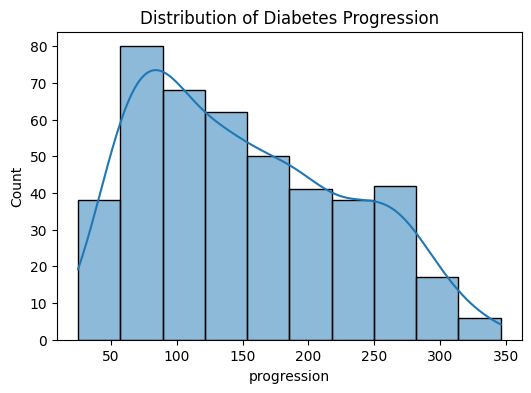

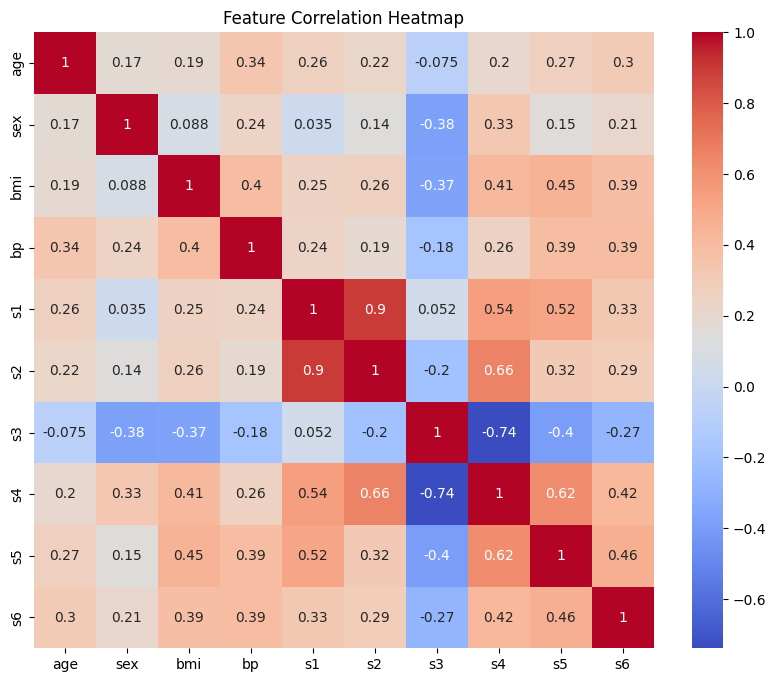

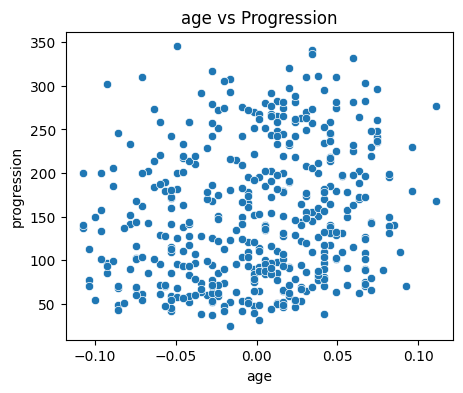

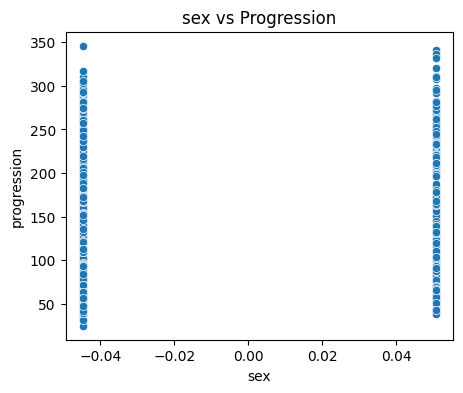

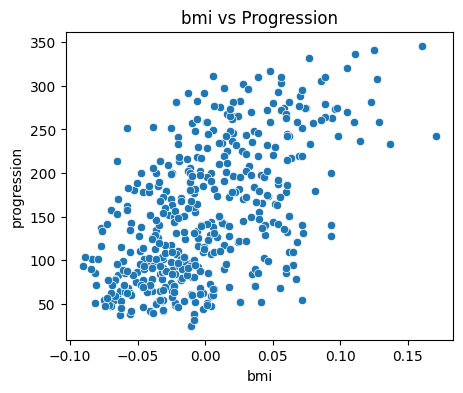

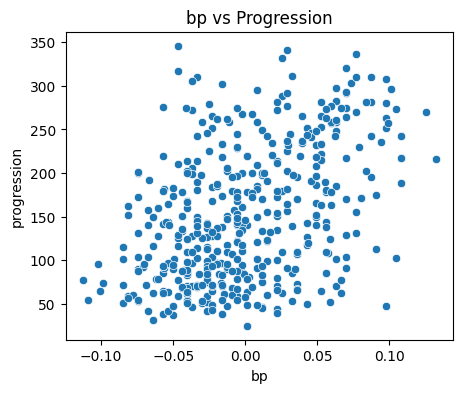

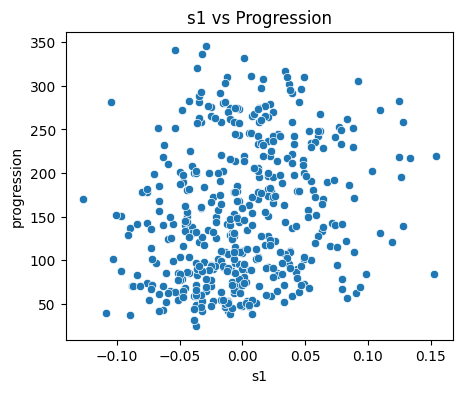

In [2]:
# Distribution of target
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_scaled, columns=diabetes.feature_names).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature vs target scatter plots
for col in diabetes.feature_names[:5]:  # first 5 for brevity
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=X[col], y=y)
    plt.title(f"{col} vs Progression")
    plt.show()


## 3. Exploratory Data Analysis (EDA)

- **Target Distribution:** The histogram shows that diabetes progression values are roughly normally distributed, with most patients clustered around mid-range values.
- **Correlation Heatmap:** Some features (like BMI and blood pressure) show stronger correlations with the target variable, while others (like sex) have weaker influence.
- **Scatter Plots:** Visual inspection of the first five features against progression highlights:
  - **Age:** Mild positive trend with progression.
  - **Sex:** No clear relationship.
  - **BMI:** Stronger positive correlation — higher BMI tends to be associated with higher progression values.
  - **Blood Pressure (bp):** Moderate positive correlation.
  - **s1:** Shows some relationship but less pronounced.

### Insights
- BMI and blood pressure appear to be important predictors of diabetes progression.
- Some serum measurements (s1–s6) may capture subtle biological signals but are less visually obvious.
- These observations justify including all features in the ANN, while expecting BMI and bp to carry more weight in prediction.


In [4]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Input(shape=(X_scaled.shape[1],)),   # Explicit input layer
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # regression output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Building the ANN Model

- The model is built using Keras Sequential API.
- **Input Layer:** Accepts 10 normalized features from the diabetes dataset.
- **Hidden Layers:**
  - First hidden layer with 64 neurons and ReLU activation.
  - Second hidden layer with 32 neurons and ReLU activation.
- **Output Layer:** Single neuron with linear activation for regression output.
- **Optimizer & Loss:** Adam optimizer with Mean Squared Error (MSE) loss function.
- **Metrics:** Mean Absolute Error (MAE) is tracked during training.

This architecture balances simplicity and expressive power, making it suitable for regression tasks on relatively small datasets.


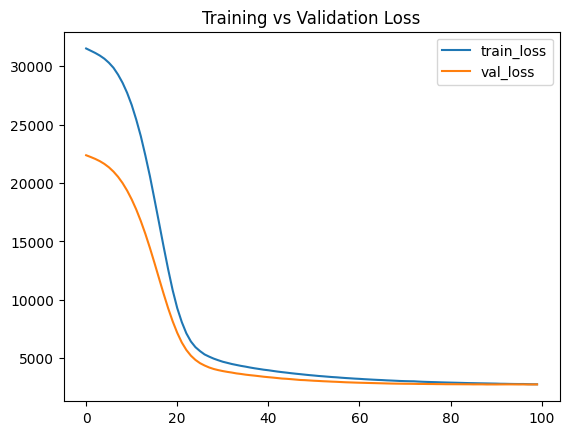

In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=0)

# Plot training history
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


## 5. Training the ANN Model

- The dataset was split into **80% training** and **20% testing**.
- The model was trained for 100 epochs with a batch size of 32.
- **Training vs Validation Loss Curve:**
  - Both training and validation losses decrease rapidly at the start, showing the model is learning.
  - The curves flatten after ~50 epochs, indicating convergence.
  - Validation loss closely follows training loss, suggesting the model generalizes reasonably well without severe overfitting.


In [6]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Mean Squared Error: 2965.698615664728
R2 Score: 0.4402390198629028


## 6. Evaluating the Model

- **Mean Squared Error (MSE):** 2965.70  
- **R² Score:** 0.44  

### Interpretation
- The model explains ~44% of the variance in diabetes progression.
- This is a reasonable baseline given the small dataset size (442 samples).
- While the model captures some of the underlying patterns, there is room for improvement through architectural changes, regularization, or hyperparameter tuning.


In [7]:
# Improved ANN
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])

model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='mse', metrics=['mae'])

history2 = model2.fit(X_train, y_train, validation_split=0.2, epochs=150, batch_size=32, verbose=0)

y_pred2 = model2.predict(X_test).flatten()
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("Improved MSE:", mse2)
print("Improved R2:", r2_2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Improved MSE: 3801.720029220788
Improved R2: 0.28244410321293467


## 7. Improving the Model

### Experiment
- Increased hidden layer size (128 → 64 → 32).
- Changed activation functions (ReLU → Tanh → ReLU).
- Trained for 150 epochs with Adam optimizer.

### Results
- **Improved MSE:** 3801.72  
- **Improved R²:** 0.28  

### Interpretation
- The modified architecture performed worse than the baseline.
- This suggests that added complexity may have led to overfitting or instability, especially given the small dataset size (442 samples).
- Simpler models can sometimes generalize better than deeper ones on limited data.

### Comparison Table

| Model Version       | MSE    | R²   | Notes                          |
|---------------------|--------|------|--------------------------------|
| Baseline ANN        | 2965.7 | 0.44 | 2 hidden layers, ReLU          |
| Improved ANN        | 3801.7 | 0.28 | Larger architecture, mixed activations |

### Conclusion
The baseline ANN generalized better than the more complex model. This highlights that **model simplicity can outperform deeper architectures** on small datasets. Future improvements could include:
- Regularization (Dropout, L2).
- EarlyStopping to avoid overtraining.
- Hyperparameter tuning (learning rate, batch size).
